# 03 - Análisis general de Radon

Este notebook analiza las funciones detectadas por Radon, sus calificaciones y su complejidad ciclomática.

In [2]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LEVEL_ORDER = {"A1": 1, "A2": 2, "B1": 3, "B2": 4, "C1": 5, "C2": 6}
LEVEL_ORDER_INV = {v: k for k, v in LEVEL_ORDER.items()}
RADON_GRADE_ORDER = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6}
RADON_GRADE_ORDER_INV = {v: k for k, v in RADON_GRADE_ORDER.items()}

def clean_file_name(path):
    """Devuelve un nombre de fichero comparable entre herramientas."""
    return Path(str(path)).name

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def detect_json_type(path):
    """Intenta detectar si un JSON parece de Radon o de PyCEFR."""
    try:
        data = load_json(path)
    except Exception:
        return "unknown"
    # Buscar un registro de ejemplo dentro del árbol project/file/[records]
    for project, files in data.items():
        if not isinstance(files, dict):
            continue
        for file_path, records in files.items():
            if isinstance(records, list) and records:
                rec = records[0]
                if isinstance(rec, dict):
                    if {"Class", "Start Line", "End Line", "Level"}.issubset(set(rec.keys())):
                        return "pycefr"
                    if {"type", "rank", "complexity", "lineno", "endline"}.issubset(set(rec.keys())):
                        return "radon"
    return "unknown"

In [3]:
df_radon = pd.read_csv(OUTPUT_DIR / "radon_functions_global.csv")
df_radon.head()
# Compatibilidad por si existe una tabla antigua con la columna "rank"
if "radon_grade" not in df_radon.columns and "rank" in df_radon.columns:
    df_radon["radon_grade"] = df_radon["rank"]
if "radon_grade_num" not in df_radon.columns and "rank_num" in df_radon.columns:
    df_radon["radon_grade_num"] = df_radon["rank_num"]


,case,project,file,file_name,type,name,complexity,rank,rank_num,lineno,endline,col_offset,parent,closure_depth,source_file
0,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_for_return,4,A,1,21,26,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_function_exists,2,A,1,12,17,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
2,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_for_type_random,2,A,1,31,35,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
3,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_function_called_for,2,A,1,41,41,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
4,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,solution.hide.py,function,generate_random,1,A,1,4,6,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...


In [4]:
grade_counts = df_radon["radon_grade"].value_counts().reindex(RADON_GRADE_ORDER.keys(), fill_value=0)
grade_counts

rank
A    106
B      3
C      0
D      0
E      0
F      0
Name: count, dtype: int64

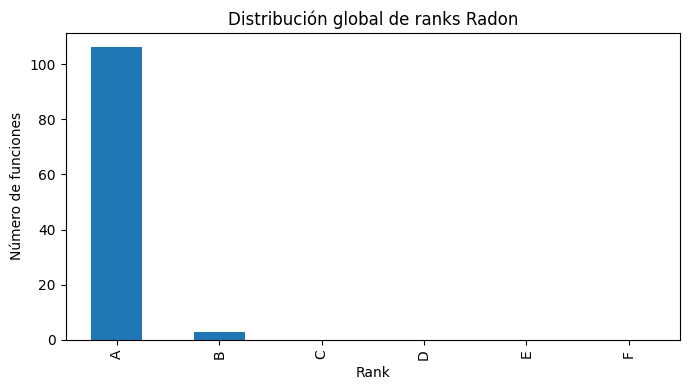

In [5]:
plt.figure(figsize=(7,4))
grade_counts.plot.bar()
plt.title("Distribución general de calificaciones de Radon")
plt.xlabel("Calificación")
plt.ylabel("Número de funciones")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_radon_distribucion_calificaciones.png", dpi=150)
plt.show()

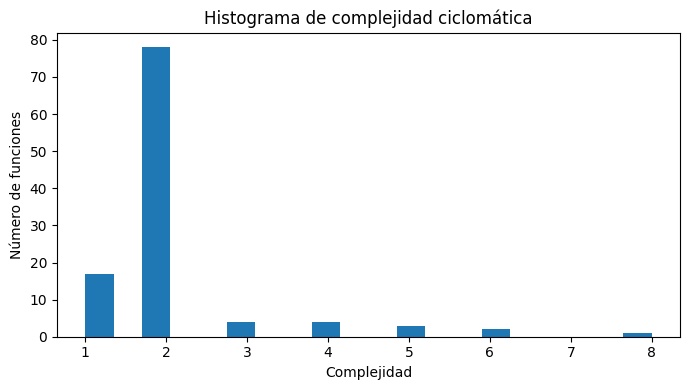

In [6]:
plt.figure(figsize=(7,4))
df_radon["complexity"].dropna().plot.hist(bins=20)
plt.title("Histograma de complejidad ciclomática")
plt.xlabel("Complejidad")
plt.ylabel("Número de funciones")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_radon_hist_complejidad.png", dpi=150)
plt.show()

In [7]:
radon_by_case = (
    df_radon.groupby("case")
    .agg(
        n_functions=("name", "count"),
        max_complexity=("complexity", "max"),
        mean_complexity=("complexity", "mean"),
        max_radon_grade_num=("radon_grade_num", "max"),
        n_closures=("parent", lambda s: s.notna().sum()),
    )
    .reset_index()
)
radon_by_case["max_radon_grade"] = radon_by_case["max_radon_grade_num"].map(RADON_GRADE_ORDER_INV)
radon_by_case.sort_values(["max_radon_grade_num", "max_complexity"], ascending=False)

,case,n_functions,max_complexity,mean_complexity,max_rank_num,n_closures,max_rank
0,python-beginner-programming-exercises,109,8,2.165138,2,0,B


In [8]:
radon_top = df_radon.sort_values("complexity", ascending=False).head(50)
radon_top

,case,project,file,file_name,type,name,complexity,rank,rank_num,lineno,endline,col_offset,parent,closure_depth,source_file
90,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_function_spin_chamber,8,B,2,11,11,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
91,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_for_function_output,6,B,2,29,29,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
42,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,solution.hide.py,function,fizz_buzz,6,B,2,1,11,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
25,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_for_file_output,5,A,1,27,27,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
33,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_for_file_output,5,A,1,27,27,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
16,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_function_return_no_static,5,A,1,40,50,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
26,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_function_output,4,A,1,20,21,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
17,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_function_returns_random_integer,4,A,1,29,36,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
0,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,function,test_for_return,4,A,1,21,26,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
76,python-beginner-programming-exercises,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,solution.hide.py,function,sing,4,A,1,2,11,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...


In [10]:
radon_by_case.to_csv(OUTPUT_DIR / "03_radon_resumen_por_caso.csv", index=False)
radon_top.to_csv(OUTPUT_DIR / "03_radon_funciones_mas_complejas.csv", index=False)

## Comentario para la memoria

Radon ofrece una visión funcional de la complejidad: cada función recibe una complejidad ciclomática y una calificación. Esto permite identificar funciones con muchos caminos de ejecución, normalmente provocados por condiciones, bucles, excepciones o combinaciones de estructuras de control.